# SIT744 Assignment 4 — Student Submission Template

This template is for organising your submission and reporting results consistently. It is **not** a worked solution. Replace all bracketed text and add your own implementation code where indicated.


## Student and submission details

- **Student name:** Keoma Borges Martins Ferreira Reis
- **Student ID:** 224790234
- **Unit code:** SIT744
- **Assignment:** Assignment 4
- **Date:** 18/05/2026


## Notes

- Keep answers short and to the point.
- Keep code outputs clean; remove excessive logs before exporting to PDF.
- Use the fixed assignment protocol from the brief: `distilgpt2`, the same tokenizer, the required three text files, perplexity, and the fixed generation prompt.
- Use one coherent pipeline across Tasks 1--3.
- The purpose of this template is to make reporting consistent for marking. You are responsible for writing and explaining your own code.


## Fixed protocol summary

| Item | Required setting |
|---|---|
| Base model | `distilgpt2` |
| Tokenizer | tokenizer associated with `distilgpt2` |
| Training text | `undrip_train.txt` |
| Validation text | `undrip_val.txt` |
| Held-out related evaluation text | `economic_test.txt` |
| Required metric | perplexity |
| Generation prompt | `Economic self-determination for First Nations peoples requires` |
| Full fine-tuning | use the fixed configuration from the assignment brief/starter guidance |
| LoRA | use the fixed LoRA configuration from the assignment brief/starter guidance |


## Fixed configuration values for required results

Use the following configuration values for the required Task 2 and Task 3 comparison. These cells specify the controlled protocol only; they do **not** provide the implementation. Do not change these values for the main results reported in the master results table.


In [1]:
# Fixed configuration values for Assignment 4.
# These are provided so all students report results under the same protocol.

BASE_MODEL = "distilgpt2"

TEXT_FILES = {
    "train": "undrip_train.txt",
    "validation": "undrip_val.txt",
    "test": "economic_test.txt",
}

GENERATION_PROMPT = "Economic self-determination for First Nations peoples requires"

TOKENISATION_CONFIG = {
    "block_size": 128,
}

# Settings for perplexity evaluation.
# These are not Hugging Face TrainingArguments.
PERPLEXITY_MAX_LENGTH = 128
PERPLEXITY_STRIDE = 128

GENERATION_CONFIG = {
    "max_new_tokens": 80,
    "do_sample": False,
}


FULL_FINE_TUNING_CONFIG = {
    "output_dir": "./distilgpt2-full-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 5e-5,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}

LORA_CONFIG = {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["c_attn"],
    "bias": "none",
    "task_type": "CAUSAL_LM",
}

# LORA_CONFIG controls the LoRA adapter itself: rank, scaling, dropout,
# and target modules.

# LORA_TRAINING_CONFIG controls how the LoRA adapter is trained. 
LORA_TRAINING_CONFIG = {
    "output_dir": "./distilgpt2-lora-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}


In [2]:
# Optional setup for Colab or a fresh environment.
# Uncomment and run this cell if the required packages are not installed.
# !pip install transformers datasets accelerate peft


## Required tokenizer and model setup

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# GPT-style tokenizers such as distilgpt2 do not define a separate padding token by default.
# Use the EOS token as the padding token so that batched training/evaluation can run.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

pretrained_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
pretrained_model.resize_token_embeddings(len(tokenizer))
pretrained_model.config.pad_token_id = tokenizer.pad_token_id

/Users/kreis/grad/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 24795.20it/s]


## Environment and imports

In [4]:
# Add or modify imports as needed for your implementation.
# Keep this cell concise.

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import math
import torch
import gc

from pathlib import Path
from datasets import Dataset
from transformers import Trainer

## Reproducibility

In [5]:
# Reproducibility
# This reduces run-to-run variation in data shuffling, model initialisation, and generation.
# Exact reproducibility is still not guaranteed on all GPU/CUDA setups.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")


Seed set to 42


# Task 1 Data preparation and pretrained baseline (25%)

In this task, prepare the three required text files and establish the pretrained baseline.


## Task 1.1 Source documents and extraction method

**Fine-tuning source document:** [Inquiry into the application of the United Nations Declaration on the Rights of Indigenous Peoples in Australia](https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Aboriginal_and_Torres_Strait_Islander_Affairs/UNDRIP/Report)

**Held-out related evaluation source document:** [Inquiry into economic self-determination and opportunities for First Nations Australians](https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Aboriginal_and_Torres_Strait_Islander_Affairs/Economicself-determinati/Report)

**Extraction method**  
I downloaded the 2 public reports and converted the PDF files to plain text using pdf24.org. I saved the extracted text as `undrip_raw.txt` and `economic_raw.txt`. I then used the provided preprocessing scaffold to clean the texts and split into an 80/20 train/validation split, and save the cleaned economic report as the held-out test file.


In [6]:
def clean_text(text):
    lines = text.splitlines()
    lines = [line.strip() for line in lines]
    lines = [line for line in lines if len(line) > 0]
    return "\n".join(lines)

def split_text(text, train_ratio=0.8):
    split_index = int(len(text) * train_ratio)
    return text[:split_index], text[split_index:]

if __name__ == '__main__':
    # Place your extracted raw plain text into these two files first.
    undrip_raw = Path("undrip_raw.txt").read_text(encoding="utf-8")
    economic_raw = Path("economic_raw.txt").read_text(encoding="utf-8")

    undrip_clean = clean_text(undrip_raw)
    economic_clean = clean_text(economic_raw)

    undrip_train, undrip_val = split_text(undrip_clean, train_ratio=0.8)

    Path("undrip_train.txt").write_text(undrip_train, encoding="utf-8")
    Path("undrip_val.txt").write_text(undrip_val, encoding="utf-8")
    Path("economic_test.txt").write_text(economic_clean, encoding="utf-8")


## Task 1.2 Data-preparation table

| File | Role | Character count | Approximate token count |
|---|---|----------------:|------------------------:|
| `undrip_train.txt` | training text |          330859 |                   66352 |
| `undrip_val.txt` | validation text |           82715 |                   16276 |
| `economic_test.txt` | held-out related evaluation text |          452566 |                   99776 |


In [7]:
# Optional: code used to compute character counts and approximate token counts.
def count(file_path):
    text = Path(file_path).read_text(encoding="utf-8")
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    return {
        "char count": len(text),
        "token count": len(token_ids),
    }

print(count("undrip_train.txt"))
print(count("undrip_val.txt"))
print(count("economic_test.txt"))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (66352 > 1024). Running this sequence through the model will result in indexing errors


{'char count': 330859, 'token count': 66352}
{'char count': 82715, 'token count': 16276}
{'char count': 452566, 'token count': 99776}


## Task 1.3 Pretrained baseline evaluation

Evaluate pretrained `distilgpt2` on `undrip_val.txt` and `economic_test.txt`. Complete only the pretrained row of the master results table at this stage.


In [8]:
# Pretrained baseline loading and perplexity evaluation code goes here.
# Use pretrained_model for the pretrained baseline.

# Perplexity guidance:
# Use model.eval(), disable gradients, and use labels=input_ids for causal language modelling.
# For long texts, use PERPLEXITY_MAX_LENGTH and PERPLEXITY_STRIDE.
def perplexity(model, tokenizer, file_path, max_length=PERPLEXITY_MAX_LENGTH, stride=PERPLEXITY_STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    text = Path(file_path).read_text(encoding="utf-8")
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids.to(device)

    seq_len = input_ids.size(1)
    nll_sum = 0.0
    n_tokens = 0
    prev_end_loc = 0

    with torch.no_grad():
        for begin_loc in range(0, seq_len, stride):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc

            input_ids_slice = input_ids[:, begin_loc:end_loc]
            target_ids = input_ids_slice.clone()
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids_slice, labels=target_ids)
            neg_log_likelihood = outputs.loss

            nll_sum += neg_log_likelihood.item() * trg_len
            n_tokens += trg_len

            prev_end_loc = end_loc

            if end_loc == seq_len:
                break

    return math.exp(nll_sum / n_tokens)

pretrained_val_ppl = perplexity(
    pretrained_model,
    tokenizer,
    "undrip_val.txt",
)

pretrained_economic_ppl = perplexity(
    pretrained_model,
    tokenizer,
    "economic_test.txt",
)

print(f"pretrained_val_ppl: {pretrained_val_ppl}")
print(f"pretrained_economic_ppl: {pretrained_economic_ppl}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


pretrained_val_ppl: 53.34027397216509
pretrained_economic_ppl: 60.87435530123492


## Master results table

Complete this table across Tasks 1-3.

Training time depends on the runtime environment, so use it mainly for comparing your own full fine-tuning and LoRA runs under the same setup.

| Model state | Parameters updated during adaptation | Training time (minutes; compare within the same runtime) | PPL on UNDRIP validation | PPL on Economic test |
|---|---:|---:|---:|---------------------:|
| Pretrained `distilgpt2` | 0  | 0 | 53.340 |               60.874 |
| Full fine-tuned `distilgpt2` | [Replace] | [Replace] | [Replace] |            [Replace] |
| LoRA-adapted `distilgpt2` | [Replace] | [Replace] | [Replace] |            [Replace] |


# Task 2 Full fine-tuning (25%)

Fine-tune `distilgpt2` once using the fixed full fine-tuning configuration. Report the result in the master results table.


In [9]:
# Start full fine-tuning from a fresh pretrained model.
model_full = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
model_full.resize_token_embeddings(len(tokenizer))
model_full.config.pad_token_id = tokenizer.pad_token_id

# Full fine-tuning code goes here.
# Use FULL_FINE_TUNING_CONFIG for the required main result.
# Keep the base model, tokenizer, training text, validation text, test text,
# evaluation metric, and generation prompt fixed.


# -------------------------------------------------------------------
# Task 2 — Full fine-tuning do distilgpt2
# -------------------------------------------------------------------
# Objetivo desta célula:
# 1. Começar de um distilgpt2 "limpo", ou seja, recém-carregado.
# 2. Preparar o arquivo undrip_train.txt como dataset de treino.
# 3. Treinar TODOS os parâmetros do modelo, que é o full fine-tuning.
# 4. Medir o tempo de treino.
# 5. Avaliar perplexity no validation set e no economic test set.
# 6. Montar uma linha com os resultados para a master results table.
#
# Importante:
# - Esta Task 2 NÃO usa LoRA.
# - LoRA só entra na Task 3.
# - Aqui todos os parâmetros do distilgpt2 ficam treináveis.
# - Usamos a configuração FULL_FINE_TUNING_CONFIG fornecida pelo template.

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# Função para transformar um arquivo .txt em dataset de linguagem
# -------------------------------------------------------------------
# O modelo distilgpt2 não recebe texto cru diretamente.
# Primeiro precisamos transformar texto em IDs de tokens usando o tokenizer.
#
# Depois quebramos esses IDs em blocos de tamanho fixo.
# O tamanho do bloco vem do template:
# TOKENISATION_CONFIG["block_size"] = 128
#
# Exemplo simplificado:
# texto -> tokenizer -> [10, 45, 88, 102, ...]
# depois dividimos em blocos:
# [10, 45, ..., 128 tokens]
# [xx, xx, ..., 128 tokens]
#
# Para causal language modelling, usamos labels iguais aos input_ids.
# O próprio AutoModelForCausalLM faz o shift interno:
# ele aprende a prever o próximo token com base nos tokens anteriores.

def build_causal_lm_dataset(file_path, tokenizer, block_size):
    text = Path(file_path).read_text(encoding="utf-8")
    token_ids = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        truncation=False,
        verbose=False,
    )["input_ids"]

    total_length = (len(token_ids) // block_size) * block_size
    token_ids = token_ids[:total_length]
    input_blocks = [
        token_ids[i : i + block_size]
        for i in range(0, total_length, block_size)
    ]

    attention_masks = [
        [1] * block_size
        for _ in input_blocks
    ]

    labels = [
        block.copy()
        for block in input_blocks
    ]

    return Dataset.from_dict({
        "input_ids": input_blocks,
        "attention_mask": attention_masks,
        "labels": labels,
    })

block_size = TOKENISATION_CONFIG["block_size"]

train_dataset = build_causal_lm_dataset(
    TEXT_FILES["train"],
    tokenizer,
    block_size,
)
print(train_dataset)

# print(f"Número de blocos de treino: {len(train_dataset)}")
# print(f"Tamanho de cada bloco: {block_size} tokens")

model_full = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
model_full.resize_token_embeddings(len(tokenizer))
model_full.config.pad_token_id = tokenizer.pad_token_id

# trying to silence warnings
model_full.config.use_cache = False

full_trainable_params = sum(
    param.numel()
    for param in model_full.parameters()
    if param.requires_grad
)

full_total_params = sum(
    param.numel()
    for param in model_full.parameters()
)

print(f"full_total_params: {full_total_params:,}")
print(f"full_trainable_params: {full_trainable_params:,}")

# setting training config to avoid random results
full_training_config = FULL_FINE_TUNING_CONFIG.copy()
full_training_config["seed"] = SEED
full_training_config["data_seed"] = SEED
full_training_args = TrainingArguments(**full_training_config)

full_trainer = Trainer(
    model=model_full,
    args=full_training_args,
    train_dataset=train_dataset,
)

start_time = time.time()
full_train_output = full_trainer.train()
end_time = time.time()
full_training_time_minutes = (end_time - start_time) / 60

full_final_training_loss = full_train_output.training_loss

print(f"full_training_time_minutes: {full_training_time_minutes:.2f} minutos")
print(f"full_final_training_loss: {full_final_training_loss:.4f}")

full_loss_history = pd.DataFrame([
    log
    for log in full_trainer.state.log_history
    if "loss" in log
])
display(full_loss_history)

full_val_ppl = perplexity(
    model_full,
    tokenizer,
    TEXT_FILES["validation"],
)

full_economic_ppl = perplexity(
    model_full,
    tokenizer,
    TEXT_FILES["test"],
)

print(f"full_val_ppl: {full_val_ppl}")
print(f"full_economic_ppl: {full_economic_ppl}")

model_full.config.use_cache = True

print({
    "Model": "Full fine-tuned distilgpt2",
    "full_trainable_params": full_trainable_params,
    "full_training_time_minutes": full_training_time_minutes,
    "full_val_ppl": full_val_ppl,
    "full_economic_ppl": full_economic_ppl,
})


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 10749.55it/s]


Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 518
})


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 10316.42it/s]


full_total_params: 81,912,576
full_trainable_params: 81,912,576


/Users/kreis/grad/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
20,3.745292
40,3.564964
60,3.651625
80,3.474890
100,3.359238
120,3.352230
140,3.373321
160,3.367283
180,3.241603
200,3.303703


full_training_time_minutes: 0.41 minutos
full_final_training_loss: 3.4354


,loss,grad_norm,learning_rate,epoch,step
0,3.745292,9.396830,0.000046,0.077220,20
1,3.564964,9.614725,0.000042,0.154440,40
2,3.651625,9.511081,0.000039,0.231660,60
3,3.474890,11.260618,0.000035,0.308880,80
4,3.359238,9.500851,0.000031,0.386100,100
5,3.352230,9.870123,0.000027,0.463320,120
6,3.373321,9.700736,0.000023,0.540541,140
7,3.367283,10.244765,0.000019,0.617761,160
8,3.241603,9.117185,0.000015,0.694981,180
9,3.303703,9.682795,0.000012,0.772201,200


full_val_ppl: 31.367053758065577
full_economic_ppl: 47.56007856620023
{'Model': 'Full fine-tuned distilgpt2', 'full_trainable_params': 81912576, 'full_training_time_minutes': 0.40528430143992106, 'full_val_ppl': 31.367053758065577, 'full_economic_ppl': 47.56007856620023}


## Task 2 evidence

Include either a training-loss curve or a compact final training-loss record.


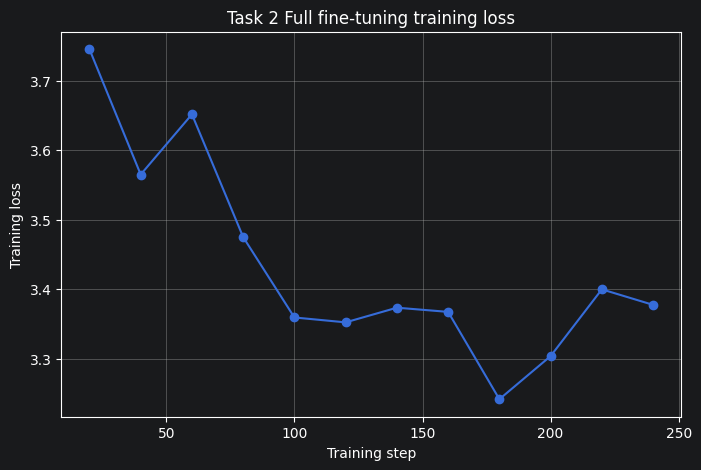

,step,loss,epoch
0,20,3.745292,0.077220
1,40,3.564964,0.154440
2,60,3.651625,0.231660
3,80,3.474890,0.308880
4,100,3.359238,0.386100
5,120,3.352230,0.463320
6,140,3.373321,0.540541
7,160,3.367283,0.617761
8,180,3.241603,0.694981
9,200,3.303703,0.772201


In [10]:
# Plot the training-loss curve or print a compact final training-loss record here.

# -------------------------------------------------------------------
# Task 2 evidence — curva de training loss
# -------------------------------------------------------------------
# O assessment pede uma curva de training loss OU um registo final claro.
# Aqui tentamos plotar a curva usando os logs do Trainer.
#
# Se por algum motivo não houver pontos suficientes para o gráfico,
# imprimimos pelo menos a training loss final.

if "full_loss_history" in globals() and len(full_loss_history) > 0:
    plt.figure(figsize=(8, 5))

    # Cada ponto mostra a loss registrada pelo Trainer em determinado step.
    plt.plot(
        full_loss_history["step"],
        full_loss_history["loss"],
        marker="o",
    )

    plt.title("Task 2 Full fine-tuning training loss")
    plt.xlabel("Training step")
    plt.ylabel("Training loss")
    plt.grid(True)
    plt.show()

    # Também mostramos a tabela compacta dos logs para deixar a evidência clara.
    display(full_loss_history[["step", "loss", "epoch"]])
else:
    print("Training-loss curve was not available.")
    print(f"Final training loss: {full_final_training_loss:.4f}")


# Task 3 LoRA adaptation and comparison (25%)

Train a LoRA-adapted version of `distilgpt2` using the fixed LoRA configuration. Reload a fresh distilgpt2 base model before applying LoRA. Do not apply LoRA to the full fine-tuned model from Task 2.
Report the result in the master results table.


In [11]:
# Start LoRA from a fresh pretrained model, not from the full fine-tuned model.
lora_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
lora_base_model.resize_token_embeddings(len(tokenizer))
lora_base_model.config.pad_token_id = tokenizer.pad_token_id

# LoRA adaptation and evaluation code goes here.
# Use LORA_CONFIG for the required main result.
lora_training_args = TrainingArguments(**LORA_TRAINING_CONFIG)
# Apply LoRA to lora_base_model and store the adapted model as lora_model.
# Do not apply LoRA on top of the full fine-tuned model for the required comparison.

# -------------------------------------------------------------------
# Task 3 — LoRA adaptation do distilgpt2
# -------------------------------------------------------------------
# Objetivo desta célula:
# 1. Carregar um distilgpt2 novo, ou seja, sem usar o full_model da Task 2.
# 2. Aplicar LoRA nesse modelo novo.
# 3. Treinar apenas os parâmetros adicionados/ativados pelo LoRA.
# 4. Avaliar perplexity no mesmo validation set e no mesmo test set.
# 5. Criar uma tabela com a linha LoRA preenchida.
#
# Importante:
# - A comparação precisa ser justa.
# - Por isso, LoRA NÃO deve ser aplicado em cima do modelo full fine-tuned.
# - O LoRA deve começar de um distilgpt2 recém-carregado.
# - O treino continua usando apenas undrip_train.txt.
# - A validação continua usando undrip_val.txt.
# - O held-out test continua usando economic_test.txt.

import gc
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType

# -------------------------------------------------------------------
# Limpeza de memória antes de treinar LoRA
# -------------------------------------------------------------------
# Neste ponto, provavelmente temos pretrained_model e full_model carregados.
# Eles são necessários depois para comparação, mas não precisam ficar na GPU agora.
# Para reduzir risco de CUDA out of memory, movemos esses modelos para CPU.

for model_name in ["pretrained_model", "full_model"]:
    if model_name in globals():
        globals()[model_name].to("cpu")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# Função para criar dataset de causal language modelling
# -------------------------------------------------------------------
# Repito a função aqui para a Task 3 ficar mais independente.
# Se você já definiu essa função na Task 2, não tem problema redefinir.
#
# O fluxo é:
# texto cru -> tokenizer -> IDs de tokens -> blocos de tamanho fixo.
#
# Cada bloco terá block_size tokens.
# Para causal language modelling, labels = input_ids.
# O modelo aprende a prever o próximo token a partir dos tokens anteriores.

def build_causal_lm_dataset(file_path, tokenizer, block_size):
    text = Path(file_path).read_text(encoding="utf-8")

    # Tokenizamos sem truncar, porque queremos usar o arquivo inteiro.
    # verbose=False evita warnings sobre o texto ser maior que a janela do modelo.
    token_ids = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        truncation=False,
        verbose=False,
    )["input_ids"]

    # Cortamos o final para que o número total de tokens seja divisível por block_size.
    # Isso evita criar um último bloco menor.
    total_length = (len(token_ids) // block_size) * block_size
    token_ids = token_ids[:total_length]

    # Criamos blocos consecutivos de tamanho fixo.
    input_blocks = [
        token_ids[i : i + block_size]
        for i in range(0, total_length, block_size)
    ]

    # Como todos os blocos têm o mesmo tamanho, a attention_mask é só 1.
    attention_masks = [
        [1] * block_size
        for _ in input_blocks
    ]

    # Em causal LM, os labels são iguais ao input.
    # O AutoModelForCausalLM faz internamente o shift para prever o próximo token.
    labels = [
        block.copy()
        for block in input_blocks
    ]

    return Dataset.from_dict({
        "input_ids": input_blocks,
        "attention_mask": attention_masks,
        "labels": labels,
    })

# -------------------------------------------------------------------
# Dataset de treino para LoRA
# -------------------------------------------------------------------
# Usamos exatamente o mesmo dataset da Task 2.
# Isso é importante porque a comparação entre full fine-tuning e LoRA
# deve mudar apenas o método de adaptação, não os dados.

block_size = TOKENISATION_CONFIG["block_size"]

lora_train_dataset = build_causal_lm_dataset(
    TEXT_FILES["train"],
    tokenizer,
    block_size,
)

print(f"Número de blocos de treino para LoRA: {len(lora_train_dataset)}")
print(f"Tamanho de cada bloco: {block_size} tokens")

# -------------------------------------------------------------------
# Carregamento de um modelo novo para LoRA
# -------------------------------------------------------------------
# Este modelo precisa começar do distilgpt2 original.
# Não usamos full_model aqui, porque isso misturaria full fine-tuning + LoRA,
# quebrando o protocolo do assessment.

lora_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
lora_base_model.resize_token_embeddings(len(tokenizer))
lora_base_model.config.pad_token_id = tokenizer.pad_token_id

# Durante treino, use_cache=False evita warnings e reduz uso desnecessário.
lora_base_model.config.use_cache = False

# -------------------------------------------------------------------
# Configuração LoRA
# -------------------------------------------------------------------
# O template já forneceu LORA_CONFIG:
#
# r = 8
#   Rank baixo usado pelo LoRA. Quanto menor, menos parâmetros treináveis.
#
# lora_alpha = 16
#   Fator de escala aplicado à atualização LoRA.
#
# lora_dropout = 0.05
#   Dropout aplicado nos caminhos LoRA durante treino.
#
# target_modules = ["c_attn"]
#   No GPT-2/distilgpt2, c_attn é a projeção combinada de query/key/value
#   usada no mecanismo de atenção.
#
# bias = "none"
#   Não treina biases adicionais.
#
# task_type = "CAUSAL_LM"
#   Indica que o modelo é de causal language modelling.

lora_config_values = LORA_CONFIG.copy()

# O template usa string "CAUSAL_LM".
# O PEFT também aceita enum TaskType.CAUSAL_LM.
# Esta conversão deixa o código mais robusto.
if lora_config_values.get("task_type") == "CAUSAL_LM":
    lora_config_values["task_type"] = TaskType.CAUSAL_LM

lora_config = LoraConfig(**lora_config_values)

# -------------------------------------------------------------------
# Aplicação do LoRA ao modelo base
# -------------------------------------------------------------------
# get_peft_model adiciona os módulos LoRA ao modelo.
# Depois disso, os pesos originais do modelo ficam congelados
# e apenas os parâmetros LoRA ficam treináveis.

lora_model = get_peft_model(lora_base_model, lora_config)

# Esta chamada imprime um resumo útil:
# - trainable params
# - total params
# - percentagem de parâmetros treináveis
lora_model.print_trainable_parameters()

# -------------------------------------------------------------------
# Contagem dos parâmetros treináveis
# -------------------------------------------------------------------
# Esta é a quantidade que deve entrar na master results table
# na linha LoRA-adapted distilgpt2.

lora_trainable_params = sum(
    param.numel()
    for param in lora_model.parameters()
    if param.requires_grad
)

lora_total_params = sum(
    param.numel()
    for param in lora_model.parameters()
)

lora_trainable_percentage = 100 * lora_trainable_params / lora_total_params

print(f"Total de parâmetros no modelo LoRA: {lora_total_params:,}")
print(f"Parâmetros treináveis no LoRA: {lora_trainable_params:,}")
print(f"Percentagem treinável no LoRA: {lora_trainable_percentage:.4f}%")

# -------------------------------------------------------------------
# TrainingArguments para LoRA
# -------------------------------------------------------------------
# Usamos a configuração fixa LORA_TRAINING_CONFIG do template.
# Não fazemos hyperparameter search, porque o assessment pede comparação controlada.
#
# Adicionamos seed e data_seed para reduzir variação entre execuções.

lora_training_config = LORA_TRAINING_CONFIG.copy()
lora_training_config["seed"] = SEED
lora_training_config["data_seed"] = SEED

lora_training_args = TrainingArguments(**lora_training_config)

# -------------------------------------------------------------------
# Trainer para LoRA
# -------------------------------------------------------------------
# O Trainer vai atualizar apenas os parâmetros que estão com requires_grad=True.
# Como get_peft_model congelou o modelo base, o treino atualiza apenas LoRA.

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=lora_train_dataset,
)

# -------------------------------------------------------------------
# Treino LoRA com medição de tempo
# -------------------------------------------------------------------
# O tempo de treino será usado na master results table.
# Compare esse tempo apenas com o full fine-tuning rodado no mesmo ambiente.

start_time = time.time()

lora_train_output = lora_trainer.train()

end_time = time.time()

lora_training_time_minutes = (end_time - start_time) / 60
lora_final_training_loss = lora_train_output.training_loss

print(f"Tempo de treino LoRA: {lora_training_time_minutes:.2f} minutos")
print(f"Training loss final LoRA: {lora_final_training_loss:.4f}")

# -------------------------------------------------------------------
# Histórico de loss do LoRA
# -------------------------------------------------------------------
# A Task 3 não exige curva de loss, mas guardar isso ajuda na análise
# e pode ser útil se você quiser comparar o comportamento do treino.

lora_loss_history = pd.DataFrame([
    log
    for log in lora_trainer.state.log_history
    if "loss" in log
])

display(lora_loss_history)

# -------------------------------------------------------------------
# Avaliação de perplexity do modelo LoRA
# -------------------------------------------------------------------
# Usamos a mesma função perplexity da Task 1.
# Isso mantém a comparação justa:
# - mesmo tokenizer
# - mesmos arquivos
# - mesmo max_length
# - mesmo stride
# - mesma métrica

lora_val_ppl = perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["validation"],
)

lora_economic_ppl = perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["test"],
)

print(f"lora_val_ppl: {lora_val_ppl}")
print(f"lora_economic_ppl: {lora_economic_ppl}")

# -------------------------------------------------------------------
# Reativamos use_cache para geração de texto
# -------------------------------------------------------------------
# Depois do treino, use_cache=True ajuda na geração.
# Isso será usado na próxima célula da generation comparison.

lora_model.config.use_cache = True

# -------------------------------------------------------------------
# Master results table atualizada até a Task 3
# -------------------------------------------------------------------
# Esta tabela junta:
# - baseline pretrained da Task 1
# - full fine-tuning da Task 2
# - LoRA da Task 3
#
# Os valores da Task 2 precisam existir no notebook.
# Se você seguiu o código anterior, eles devem estar nas variáveis:
# full_trainable_params, full_training_time_minutes, full_val_ppl, full_economic_ppl.

task3_master_results_table = pd.DataFrame([
    {
        "Model state": "Pretrained distilgpt2",
        "Parameters updated during adaptation": 0,
        "Training time (minutes; compare within same runtime)": 0,
        "PPL on UNDRIP validation": pretrained_val_ppl,
        "PPL on Economic test": pretrained_economic_ppl,
    },
    {
        "Model state": "Full fine-tuned distilgpt2",
        "Parameters updated during adaptation": globals().get("full_trainable_params", None),
        "Training time (minutes; compare within same runtime)": globals().get("full_training_time_minutes", None),
        "PPL on UNDRIP validation": globals().get("full_val_ppl", None),
        "PPL on Economic test": globals().get("full_economic_ppl", None),
    },
    {
        "Model state": "LoRA-adapted distilgpt2",
        "Parameters updated during adaptation": lora_trainable_params,
        "Training time (minutes; compare within same runtime)": lora_training_time_minutes,
        "PPL on UNDRIP validation": lora_val_ppl,
        "PPL on Economic test": lora_economic_ppl,
    },
])

task3_master_results_table


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 12043.04it/s]


Número de blocos de treino para LoRA: 518
Tamanho de cada bloco: 128 tokens


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 8522.05it/s]
/Users/kreis/grad/.venv/lib/python3.14/site-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797
Total de parâmetros no modelo LoRA: 82,060,032
Parâmetros treináveis no LoRA: 147,456
Percentagem treinável no LoRA: 0.1797%


/Users/kreis/grad/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
20,3.912324
40,3.911057
60,4.035173
80,3.907057
100,3.840323
120,3.809565
140,3.851002
160,3.798187
180,3.702686
200,3.734011


Tempo de treino LoRA: 0.20 minutos
Training loss final LoRA: 3.8596


,loss,grad_norm,learning_rate,epoch,step
0,3.912324,0.227272,0.000093,0.077220,20
1,3.911057,0.300939,0.000085,0.154440,40
2,4.035173,0.323168,0.000077,0.231660,60
3,3.907057,0.577884,0.000069,0.308880,80
4,3.840323,0.499914,0.000062,0.386100,100
5,3.809565,0.551255,0.000054,0.463320,120
6,3.851002,0.478323,0.000046,0.540541,140
7,3.798187,0.609105,0.000039,0.617761,160
8,3.702686,0.565506,0.000031,0.694981,180
9,3.734011,0.635913,0.000023,0.772201,200


lora_val_ppl: 46.88389397659971
lora_economic_ppl: 54.43052729258307


,Model state,Parameters updated during adaptation,Training time (minutes; compare within same runtime),PPL on UNDRIP validation,PPL on Economic test
0,Pretrained distilgpt2,0,0.000000,53.340274,60.874355
1,Full fine-tuned distilgpt2,81912576,0.405284,31.367054,47.560079
2,LoRA-adapted distilgpt2,147456,0.202012,46.883894,54.430527


## Generation comparison table

Use the fixed generation prompt exactly. Keep outputs short enough to be readable in the exported PDF.

| Prompt | Pretrained output | Full fine-tuned output | LoRA-adapted output | One-sentence comparison |
|---|---|---|---|---|
| `Economic self-determination for First Nations peoples requires` | [Replace] | [Replace] | [Replace] | [Replace] |


In [12]:
# Generation code for pretrained_model, full_model, and lora_model goes here.
# Use GENERATION_PROMPT and GENERATION_CONFIG for the required comparison.

# -------------------------------------------------------------------
# Task 3 — Generation comparison table
# -------------------------------------------------------------------
# Objetivo desta célula:
# Comparar a saída dos três estados do modelo:
# 1. pretrained_model
# 2. full_model
# 3. lora_model
#
# O assessment exige usar exatamente este prompt:
# "Economic self-determination for First Nations peoples requires"
#
# Também usamos GENERATION_CONFIG do template:
# max_new_tokens = 80
# do_sample = False
#
# do_sample=False significa geração determinística/greedy.
# Assim, o resultado tende a ser mais estável entre execuções.

def generate_continuation(model, tokenizer, prompt, generation_config):
    # Seleciona GPU se estiver disponível, caso contrário usa CPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move o modelo para o device correto e coloca em modo avaliação.
    model.to(device)
    model.eval()

    # Tokeniza o prompt fixo.
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=generation_config["max_new_tokens"],
            do_sample=generation_config["do_sample"],
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # generated_ids contém prompt + continuação.
    # Para a tabela ficar mais limpa, pegamos apenas os tokens novos.
    prompt_length = inputs["input_ids"].shape[-1]
    continuation_ids = generated_ids[0][prompt_length:]

    continuation = tokenizer.decode(
        continuation_ids,
        skip_special_tokens=True,
    )

    # Limpamos espaços e quebras excessivas para a tabela não ficar enorme.
    continuation = " ".join(continuation.split())

    return continuation

# -------------------------------------------------------------------
# Geração com o modelo pretrained
# -------------------------------------------------------------------
# Este é o baseline sem adaptação.
# Ele mostra como o distilgpt2 original continua o prompt.

pretrained_output = generate_continuation(
    pretrained_model,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

# Depois de gerar, movemos para CPU para liberar GPU para o próximo modelo.
pretrained_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# Geração com o modelo full fine-tuned
# -------------------------------------------------------------------
# Este modelo foi adaptado atualizando todos os parâmetros.
# A saída deve ser comparada com a perplexity e com o output LoRA.

full_output = generate_continuation(
    model_full,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

model_full.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# Geração com o modelo LoRA
# -------------------------------------------------------------------
# Este modelo foi adaptado treinando apenas os parâmetros LoRA.
# A comparação principal é verificar se ele captura parte do estilo/domínio
# com muito menos parâmetros treináveis.

lora_output = generate_continuation(
    lora_model,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

lora_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# Frase curta de comparação
# -------------------------------------------------------------------
# Esta frase ainda é provisória.
# Depois de você rodar e ver os outputs reais, pode ajustar com base nos resultados.
#
# O importante é que a comparação final da Task 4 mencione:
# - master results table
# - generation comparison table
# - perplexity
# - parâmetros treináveis
# - tempo de treino

one_sentence_comparison = (
    "The pretrained model is the baseline, while the full fine-tuned and LoRA-adapted "
    "outputs should be compared using their domain relevance, coherence, perplexity, "
    "training time, and number of trainable parameters."
)

generation_comparison_table = pd.DataFrame([
    {
        "Prompt": GENERATION_PROMPT,
        "Pretrained output": pretrained_output,
        "Full fine-tuned output": full_output,
        "LoRA-adapted output": lora_output,
        "One-sentence comparison": one_sentence_comparison,
    }
])

generation_comparison_table

,Prompt,Pretrained output,Full fine-tuned output,LoRA-adapted output,One-sentence comparison
0,Economic self-determination for First Nations ...,a strong commitment to the rights of all peoples.,a national government to implement the Declara...,a comprehensive and comprehensive internationa...,"The pretrained model is the baseline, while th..."


# Task 4 Interpretation and learning reflection (20%)

This task is about explanation and evidence of your individual learning.


## Task 4A Technical interpretation (15%)

Answer the following questions in at most **300 words** total. Your answers must refer to your own master results table and generation comparison table.

1. Using your reported perplexity values, what do your results show about adaptation to `undrip_val.txt` versus transfer to `economic_test.txt`?
2. Using your reported trainable-parameter count, training time, perplexity values, and generation comparison, what trade-off do you observe between full fine-tuning and LoRA?
3. Based on your own results, which method would you recommend under limited compute for a quick domain-adaptation baseline, and why?

Before writing, look at your master results table and generation comparison table. Your discussion should refer to your own reported values. For example: "Full fine-tuning reduced PPL on UNDRIP validation from X to Y, while LoRA reduced it to Z."

**Your response:**  
Write your Task 4A response here. Keep the total response to at most 300 words and base your claims on your reported results.


## Task 4B Learning reflection (5%)

Answer the following question in at most **150 words**.

Over the 11 weeks of this unit, what is one intuition about deep learning that has changed, become clearer, or become more nuanced for you?

Your answer should include:

- one earlier intuition, assumption, or misconception;
- the concept, activity, result, lecture, practical, or example that changed or refined it;
- what you now understand differently;
- how this would affect the way you approach a future deep learning problem.

**Your response:**  
[Replace]


# Final checklist

- [ ] The notebook filename follows the required format.
- [ ] The PDF export filename follows the required format.
- [ ] `undrip_train.txt`, `undrip_val.txt`, and `economic_test.txt` are submitted.
- [ ] The 80/20 UNDRIP split is followed.
- [ ] All modelling tasks use the text files created in Task 1.
- [ ] The data-preparation table is completed.
- [ ] The master results table is completed.
- [ ] A training-loss curve or compact final training-loss record is included.
- [ ] The generation comparison table is completed.
- [ ] The fixed generation prompt is used exactly.
- [ ] Perplexity is reported consistently.
- [ ] The technical interpretation is concise.
- [ ] My technical interpretation refers to my own master results table and generation comparison table.
- [ ] The learning reflection identifies a concrete change in understanding.
- [ ] Code outputs are cleaned before PDF export.
- [ ] Cloud resources are shut down after use.
